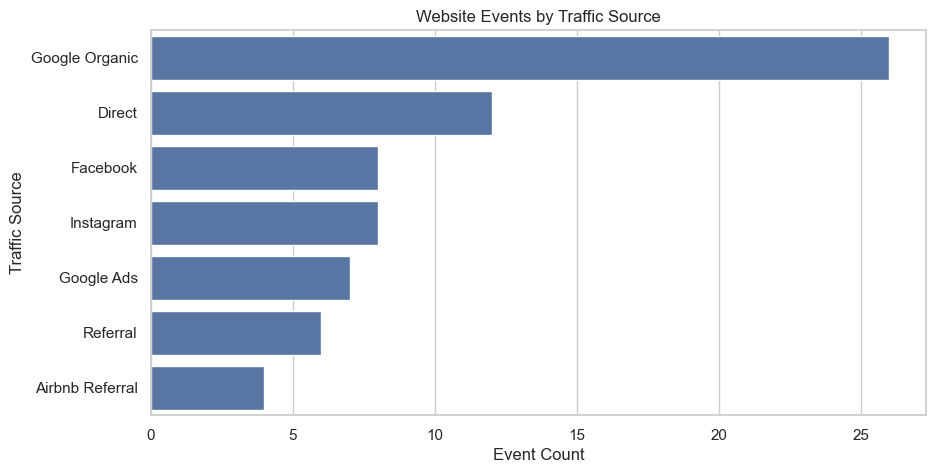

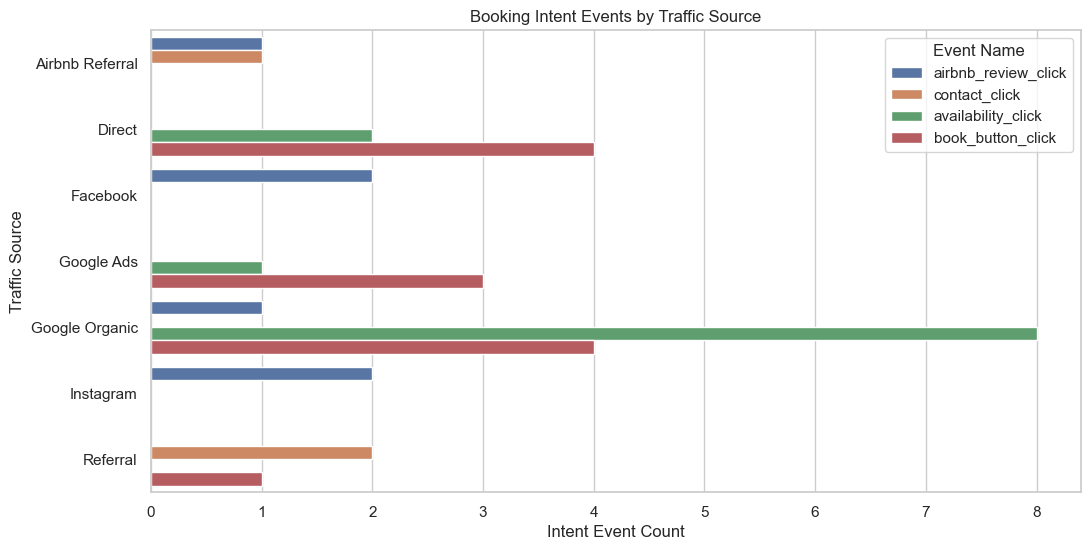

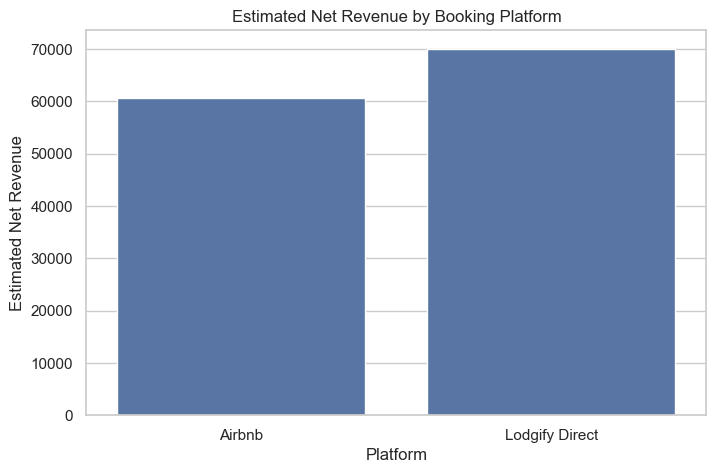

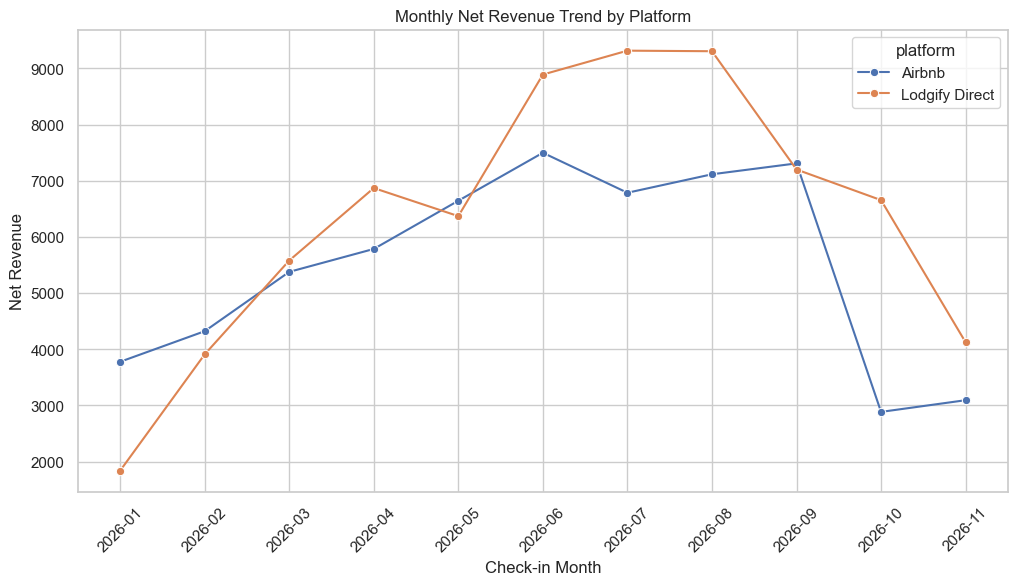

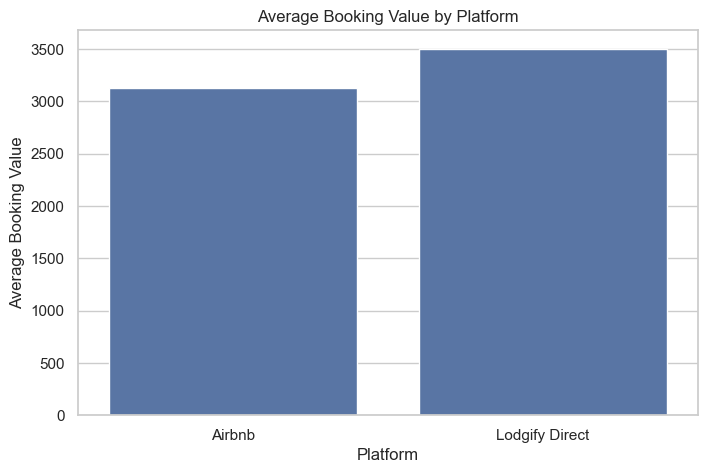

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("data_sample")

#cleaned data
website = pd.read_csv(DATA_PATH / "clean_website_events.csv")
lodgify = pd.read_csv(DATA_PATH / "clean_lodgify_bookings.csv")
airbnb = pd.read_csv(DATA_PATH / "clean_airbnb_bookings.csv")

website.head(), lodgify.head(), airbnb.head()

#traffic by source
traffic_by_source = website.groupby("traffic_source").size().reset_index(name="event_count")
traffic_by_source = traffic_by_source.sort_values("event_count", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=traffic_by_source, x="event_count", y="traffic_source")
plt.title("Website Events by Traffic Source")
plt.xlabel("Event Count")
plt.ylabel("Traffic Source")
plt.show()

traffic_by_source

#booking intent by source
booking_intent = website[website["event_name"].isin([
    "book_button_click",
    "availability_click",
    "airbnb_review_click",
    "contact_click"
])]

intent_by_source = booking_intent.groupby(["traffic_source", "event_name"]).size().reset_index(name="count")

plt.figure(figsize=(12, 6))
sns.barplot(data=intent_by_source, x="count", y="traffic_source", hue="event_name")
plt.title("Booking Intent Events by Traffic Source")
plt.xlabel("Intent Event Count")
plt.ylabel("Traffic Source")
plt.legend(title="Event Name")
plt.show()

intent_by_source

#combine airbnb and lodgify
lodgify_compare = lodgify.copy()
lodgify_compare["platform"] = "Lodgify Direct"
lodgify_compare["net_revenue"] = lodgify_compare["estimated_net_revenue"]

airbnb_compare = airbnb.copy()
airbnb_compare["platform"] = "Airbnb"

common_columns = [
    "booking_id",
    "booking_date",
    "check_in",
    "check_out",
    "nights",
    "guest_count",
    "gross_revenue",
    "net_revenue",
    "status",
    "booking_month",
    "check_in_month",
    "platform",
    "revenue_per_night"
]

all_bookings = pd.concat([
    lodgify_compare[common_columns],
    airbnb_compare[common_columns]
], ignore_index=True)

all_bookings.head()

#revenue by platform
revenue_by_platform = all_bookings.groupby("platform").agg(
    total_gross_revenue=("gross_revenue", "sum"),
    total_net_revenue=("net_revenue", "sum"),
    avg_booking_value=("gross_revenue", "mean"),
    booking_count=("booking_id", "count"),
    avg_revenue_per_night=("revenue_per_night", "mean")
).reset_index()

revenue_by_platform

plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_by_platform, x="platform", y="total_net_revenue")
plt.title("Estimated Net Revenue by Booking Platform")
plt.xlabel("Platform")
plt.ylabel("Estimated Net Revenue")
plt.show()

#monthly revenue
monthly_revenue = all_bookings.groupby(["check_in_month", "platform"]).agg(
    monthly_net_revenue=("net_revenue", "sum")
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x="check_in_month", y="monthly_net_revenue", hue="platform", marker="o")
plt.title("Monthly Net Revenue Trend by Platform")
plt.xlabel("Check-in Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.show()

monthly_revenue

#avg booking value
plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_by_platform, x="platform", y="avg_booking_value")
plt.title("Average Booking Value by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Booking Value")
plt.show()


In [ ]:
# Initial Business Insights

#1. Google Organic and Direct traffic appear to generate strong booking-intent activity.
#2. Airbnb provides booking volume, but direct/Lodgify bookings may create stronger net revenue depending on platform fees.
#3. Airbnb review clicks should be treated as a trust signal. Visitors may use Airbnb reviews to validate the property before booking direct.
#4. Direct-booking conversion should be tracked closely because even small improvements could increase retained revenue.
#5. The next website improvement should focus on making the direct booking call-to-action clearer on high-traffic pages.